# 05 Hyperparameter Tuning for Student Outcome Prediction

This notebook presents a structured hyperparameter optimization process for multiclass student outcome prediction.

- **Dataset**: `../data/data_preprocessed.csv`
- **Target variable**: `Target_encoded`
- **Candidate models**: Decision Tree and Logistic Regression
- **Search strategy**: `GridSearchCV` with 5-fold cross-validation
- **Primary selection metric**: `F1-macro`

The objective is to identify model configurations that improve class-balanced predictive performance while preserving generalization on the held-out test set.


In [5]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier


In [6]:
def evaluate_model(model_name, search, x_test, y_test):
    y_pred = search.predict(x_test)
    return {
        "model": model_name,
        "best_params": search.best_params_,
        "cv_best_f1_macro": search.best_score_,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_f1_macro": f1_score(y_test, y_pred, average="macro"),
        "classification_report": classification_report(y_test, y_pred),
    }


In [7]:
project_root = Path("..").resolve()
data_path = project_root / "data" / "data_preprocessed.csv"
outputs_dir = project_root / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)
x = df.drop(columns=["Target", "Target_encoded"])
y = df["Target_encoded"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y
)

dt_params = {
    "max_depth": [3, 5, 8, 12, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy", "log_loss"],
}

dt_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1,
)
dt_search.fit(x_train, y_train)

lr_params = {
    "C": [0.01, 0.1, 1, 3, 10],
    "solver": ["lbfgs", "newton-cg", "saga"],
    "max_iter": [1000, 2000],
}

lr_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=lr_params,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1,
)
lr_search.fit(x_train, y_train)

results = [
    evaluate_model("DecisionTree", dt_search, x_test, y_test),
    evaluate_model("LogisticRegression", lr_search, x_test, y_test),
]


Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [8]:
results_df = pd.DataFrame(
    [
        {
            "model": r["model"],
            "cv_best_f1_macro": r["cv_best_f1_macro"],
            "test_accuracy": r["test_accuracy"],
            "test_f1_macro": r["test_f1_macro"],
            "best_params": json.dumps(r["best_params"], ensure_ascii=False),
        }
        for r in results
    ]
).sort_values(by="test_f1_macro", ascending=False)

csv_path = outputs_dir / "hyperparameter_tuning_results.csv"
txt_path = outputs_dir / "hyperparameter_tuning_report.txt"
json_path = outputs_dir / "hyperparameter_best_params.json"

results_df.to_csv(csv_path, index=False)

with open(txt_path, "w", encoding="utf-8") as f:
    for r in results:
        f.write(f"Model: {r['model']}\n")
        f.write(f"Best Params: {r['best_params']}\n")
        f.write(f"Best CV F1-macro: {r['cv_best_f1_macro']:.4f}\n")
        f.write(f"Test Accuracy: {r['test_accuracy']:.4f}\n")
        f.write(f"Test F1-macro: {r['test_f1_macro']:.4f}\n\n")
        f.write("Classification Report:\n")
        f.write(r["classification_report"])
        f.write("\n" + "=" * 80 + "\n\n")

with open(json_path, "w", encoding="utf-8") as f:
    json.dump({r["model"]: r["best_params"] for r in results}, f, indent=2)

results_df


,model,cv_best_f1_macro,test_accuracy,test_f1_macro,best_params
1,LogisticRegression,0.691910,0.778614,0.708563,"{""C"": 1, ""max_iter"": 1000, ""solver"": ""lbfgs""}"
0,DecisionTree,0.671436,0.744729,0.663908,"{""criterion"": ""entropy"", ""max_depth"": 8, ""min_..."


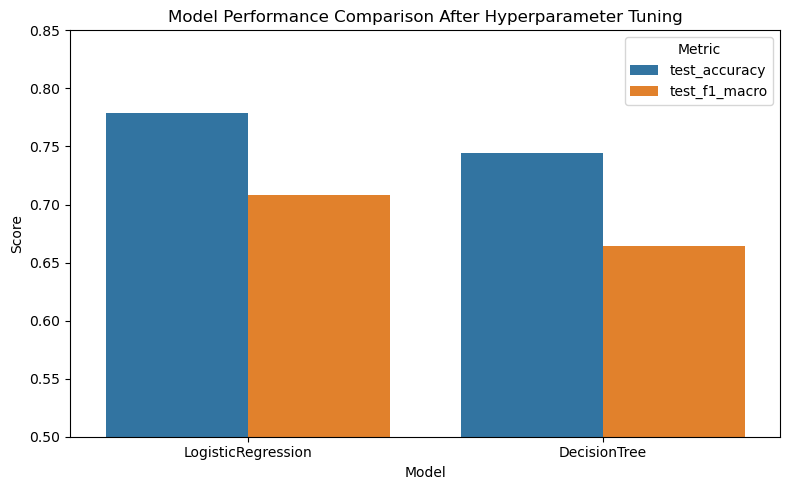

Plot saved to: C:\Users\asus\Desktop\machine-learning-main\outputs\hyperparameter_model_comparison.png


In [9]:
# Visual comparison for report/PPT
plot_df = results_df[["model", "test_accuracy", "test_f1_macro"]].melt(
    id_vars="model", var_name="metric", value_name="score"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.ylim(0.5, 0.85)
plt.title("Model Performance Comparison After Hyperparameter Tuning")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend(title="Metric")
plt.tight_layout()

plot_path = outputs_dir / "hyperparameter_model_comparison.png"
plt.savefig(plot_path, dpi=150)
plt.show()

print(f"Plot saved to: {plot_path}")

## Conclusion

Hyperparameter optimization results indicate that **Logistic Regression** outperforms **Decision Tree** on both `test_accuracy` and `test_f1_macro`, suggesting better overall generalization under the current feature set. In particular, the macro-level improvement confirms that performance gains are not limited to only the majority class.

However, class-wise evaluation still shows weaker recognition for class `1`, indicating persistent inter-class overlap and/or class imbalance effects. For subsequent iterations, we recommend testing class-balancing strategies (e.g., weighted loss or resampling) and comparing additional non-linear models to further improve minority-class performance.
